# Simulate data using behavioral model and perform parameter recovery

There are 3 models with different parameter combinations:

1. <b>The Bayesian model (Schwöbel et al. 2021):</b> \
   <b>a.</b> With 3 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, and a decision temparature $\beta$. \
   <b>b.</b> With 4 parameters: a policy forgetting rate $\lambda_{\pi}$, a reward forgetting rate $\lambda_{r}$, a decision temparature $\beta$, and a habitual tendency $h$.
2. <b>A newer MF/MB version that is better for fitting (Otto et al. 2013):</b> \
<b>Note:</b> This is not quite the original version, as the Q-values in the original work did not converge to the true expected values. Instead, I implemented a "bug-fixed" version.\
   <b>a.</b> With 4 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a MF weight parameter $\beta_{MF}$, a MB weight parameter $\beta_{MB}$, a learning rate $\alpha$, and a dicount factor $\lambda$$, and a repetition/perserveration parameter $p$. \
3. <b>The original model-free/model-based (MF/MB) model (Daw et al. 2005, 2011):</b> \
   <b>a.</b> With 4 parameters: a weighting parameters $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, and a dicount factor $\lambda$. \
   <b>b.</b> With 5 parameters: a weighting parameter $\omega$, a decision temperature $\beta$, a learning rate $\alpha$, a dicount factor $\lambda$, and a repetition/perserveration parameter $p$.

Tell python that the code in the submodule is code that we want to import and run

In [1]:
import sys
import os
current_dir = os.path.abspath('')
os.chdir(current_dir)
sys.path.append(os.path.join(current_dir,'..','..','code','BalancingControl'))

import two_stage_utils as tu
import inference as inf
import inference_utils as iu

torch threads 1


/home/sarah/python_venvs/TwoStageStrategies/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running on device cpu
torch threads 1


Other imports that we need for simulation, inference, and plotting

In [2]:
import torch
import pyro

import os
from scipy.io import loadmat
import matplotlib.pylab as plt
import seaborn as sns
import pandas as pd
import glob
import jsonpickle as pickle
import json
import gc
# import pickle

Define where results should be saved

In [3]:
results_folder = "results"
simulation_folder = os.path.join(results_folder, "simulations")
recovery_folder = os.path.join(results_folder, "recovery")

cross_fitting_folder = os.path.join(results_folder, "cross_fitting")

# processed_data_folder = os.path.join("processed_data")

Where pre-processed info is found

In [4]:
# results_folder = os.path.join("results")
processed_data_folder = os.path.join("processed_data")

mask_file_name = "mask.pkl"
mask_file = os.path.join(processed_data_folder, mask_file_name)

Rho_fname = "Rho.pkl"
Rho_file = os.path.join(processed_data_folder, Rho_fname)

#### Global experiment parameters

In [5]:
# number of simulated agents/participants
n_agents = 24

In [6]:
trials =  272#number of trials
T = 3 #number of time steps in each trial
nb = 4 # number of bandits, ie second level rewards
ns = 3+nb #number of states
no = ns #number of observations
na = 2 #number of actions
npi = na**(T-1) #number of policies
nr = 2 #number of rewards
never_reward = ns-nb # states that dont generate rewards

# prob for invalid answer (e.g. no reply). Same frequency as in the real data
with open(mask_file, 'r') as infile:
    loaded = json.load(infile)
all_mask = pickle.decode(loaded)
# simulations will be done with the same missing actions as in the data.
exp_mask = torch.tensor(all_mask)#.permute((1,0))
# exp mask knows the subject specific lengths
p_valid = exp_mask.sum()/(exp_mask.shape[0]*exp_mask.shape[1])
print(p_valid)

# make global parameter dict:
global_experiment_parameters = {"trials": trials, "T": T, "nb": nb, "ns": ns, "no": no, "na": na, "npi": npi, "nr": nr, "never_reward": never_reward, "p_invalid": p_valid, "mask": exp_mask}

tensor(0.7390)


Define states and transition matrices

In [7]:
#generating probability of observations in each state / unity matrix
A = torch.eye(no)


#state transition generative probability (matrix)
B = torch.zeros((ns, ns, na))
b1 = 0.7
nb1 = 1.-b1
b2 = 0.7
nb2 = 1.-b2

B[:,:,0] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [ b1,  0,  0,  0,  0,  0,  0,],
                         [nb1,  0,  0,  0,  0,  0,  0,],
                         [  0,  1,  0,  1,  0,  0,  0,],
                         [  0,  0,  1,  0,  1,  0,  0,],
                         [  0,  0,  0,  0,  0,  1,  0,],
                         [  0,  0,  0,  0,  0,  0,  1,],])

B[:,:,1] = torch.tensor([[  0,  0,  0,  0,  0,  0,  0,],
                         [nb2,  0,  0,  0,  0,  0,  0,],
                         [ b2,  0,  0,  0,  0,  0,  0,],
                         [  0,  0,  0,  1,  0,  0,  0,],
                         [  0,  0,  0,  0,  1,  0,  0,],
                         [  0,  1,  0,  0,  0,  1,  0,],
                         [  0,  0,  1,  0,  0,  0,  1,],])

# add to parameter dict
global_experiment_parameters["A"] = A
global_experiment_parameters["B"] = B

Load and plot reward probabilities

In [8]:
with open(Rho_file, 'r') as infile:
    loaded = json.load(infile)
Rho = pickle.decode(loaded)

# add to parameter dict
global_experiment_parameters["Rho"] = torch.from_numpy(Rho)

Now we can start :) 

Load stored simulation results of BCC3

Simulation pre-setup

In [9]:
# set parameters and their names

learn_rewards = True
learn_habit = True
use_h = False
learn_cached = False

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

# prepare for saving results
# make base filename and folder string
agent_type_data = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(agent_type_data)
fname_base_data = agent_type_data+"_simulation_"
print(fname_base_data)
# define folder where we want to save data
base_dir = os.path.join(simulation_folder,fname_base_data[:-1])

BCC_4pars_planning_repetition_weight
BCC_4pars_planning_repetition_weight_simulation_


In [10]:
print("loading simulated outputs...")

stayed_arr, true_vals, data = tu.load_simulation_outputs(base_dir, agent_type_data)

n_true = true_vals["subject"].max() + 1
n_data = data["subject"].max() + 1

assert n_true == n_data == n_agents, f"the numbers of agents dont match! They are: {n_true}, {n_data}, {n_agents}. Probably rerun simulations to fix."

print("true values are:")
print(true_vals)

loading simulated outputs...
true values are:
{'subject': tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23]]), 'dec temp': tensor([[1.0767, 3.5581, 2.7415, 3.7217, 2.9226, 4.3425, 5.3497, 1.8657, 1.0150,
         4.7846, 3.3606, 5.9965, 5.0355, 1.7968, 5.4791, 1.2597, 2.3914, 4.9150,
         5.3532, 3.4427, 1.7319, 4.4369, 1.5243, 1.1032]]), 'reward rate': tensor([[0.1463, 0.0049, 0.5277, 0.5901, 0.0733, 0.8279, 0.3180, 0.8659, 0.5627,
         0.7619, 0.2868, 0.7650, 0.1924, 0.4175, 0.0223, 0.9386, 0.9032, 0.3540,
         0.6257, 0.7384, 0.9074, 0.2527, 0.1935, 0.7303]]), 'habitual tendency': tensor([[3.7559, 1.4084, 1.4153, 3.2988, 5.2802, 2.2342, 4.9702, 1.7170, 1.8659,
         5.9561, 4.3471, 5.7365, 2.7053, 4.1672, 3.8069, 2.2102, 3.2644, 5.8419,
         2.4852, 2.8304, 3.7166, 4.7310, 5.0914, 4.9169]]), 'policy rate': tensor([[2.6569e-01, 6.7016e-01, 7.7953e-01, 8.7200e-01, 7.5694e-01, 7.2388e-01,
         1.2523

Plot simulated stay probability

/tmp/ipykernel_17051/2856057762.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(bar_names, rotation=45, horizontalalignment='right', fontsize=16)


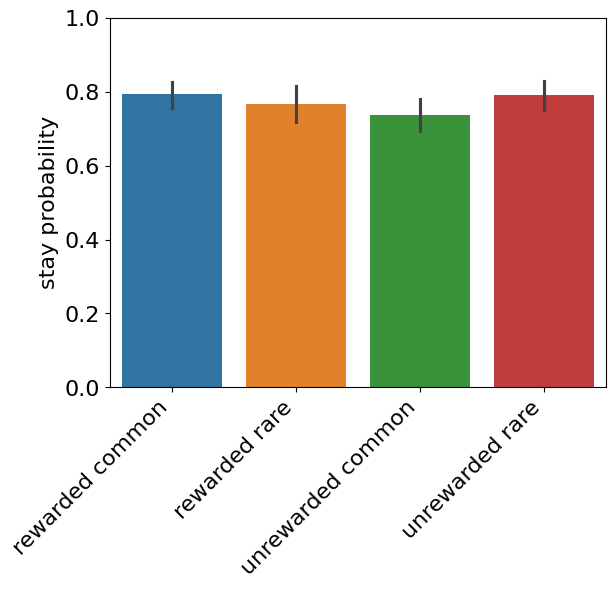

In [11]:
bar_names = ["rewarded common", "rewarded rare", "unrewarded common", "unrewarded rare"]

plt.figure()
g = sns.barplot(data=stayed_arr)
g.set_xticklabels(bar_names, rotation=45, horizontalalignment='right', fontsize=16)
plt.ylim([0,1])
plt.yticks(torch.arange(0,1.1,0.2),fontsize=16)
plt.ylabel("stay probability", fontsize=16)
# plt.title(fname_base[:-1], fontsize=16)
# plt.savefig(os.path.join(base_dir,"simulated_stay_probs.svg"),dpi=300)
plt.show()

#### Inference: we will analyze BCC2_planning data with the BCC4_planning_repetition model

Simulation pre-setup

In [12]:
# set parameters and their names

learn_rewards = True
learn_habit = False
use_h = False
learn_cached = True

param_names = []
param_ranges = []

prefix = "BCC"
model_name = "Bayesian prior-based contextual control model"
n_pars = 0
agnt_str = ""

if learn_rewards:
    n_pars += 2
    param_names += ["dec temp", "reward rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_planning"

if learn_habit:
    # infer_h = True
    # infer_policy_rate = True 
    n_pars += 2
    agnt_str += "_repetition"
    param_names += ["habitual tendency", "policy rate"]
    if use_h:
        agnt_str += "_h"
        param_ranges += [[0,1], [0,1]]
    else:
        agnt_str += "_weight"
        param_ranges += [[0,8], [0,1]]
# else:
#     infer_h = False
#     infer_policy_rate = False

if learn_cached:
    n_pars += 2
    param_names += ["cached weight", "cached rate"]
    param_ranges += [[0,8], [0,1]]
    agnt_str += "_cached"

assert n_pars > 0, "please turn any part of the agent on, it cannot run without any learning or inference."

# choose max decision temperature for numerical stability
max_dt = 6

# prepare for saving results
# make base filename and folder string
agent_type = prefix+"_"+str(n_pars)+"pars"+agnt_str
print(agent_type)

BCC_4pars_planning_cached


Inference pre-setup

In [13]:
# prepare for saving results
# make base filename and folder string
fname_base = agent_type_data+"_cross_fitting_"+agent_type
print(fname_base)
# define folder where we want to save data
base_dir = os.path.join(cross_fitting_folder,fname_base[:-1])

# make directory if it doesnt exist
if fname_base[:-1] not in os.listdir(cross_fitting_folder):
    os.mkdir(base_dir)

# how many inference steps
num_steps = 600

BCC_4pars_planning_repetition_weight_cross_fitting_BCC_4pars_planning_cached


<b>Decide</b> for running or loading inference

In [14]:
run_inference = True

<b>Either:</b> Set up agent and inference. Run main inference loop, plot intermediate and end results

/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/perception.py:142: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  self.big_trans_matrix = ar.stack([ar.stack([generative_model_states[:,:,policies[pi,t]] for pi in range(self.npi)]) for t in range(self.T-1)]).T.to(device)


4
analyzing 24 data sets
this is inference using <class 'inference.GeneralGroupInference'>
taking steps 1 to 100 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 10608.41:   0%|          | 0/100 [00:11<?, ?it/s]

Mean ELBO 10608.41:   1%|          | 1/100 [00:11<18:53, 11.45s/it]

...

Mean ELBO 8383.46:  98%|█████████▊| 98/100 [10:49<00:12,  6.47s/it]

Mean ELBO 8383.46:  99%|█████████▉| 99/100 [10:49<00:06,  6.33s/it]

Mean ELBO 8366.94:  99%|█████████▉| 99/100 [10:56<00:06,  6.33s/it]

Mean ELBO 8366.94: 100%|██████████| 100/100 [10:56<00:00,  6.43s/it]

Mean ELBO 8366.94: 100%|██████████| 100/100 [10:56<00:00,  6.56s/it]

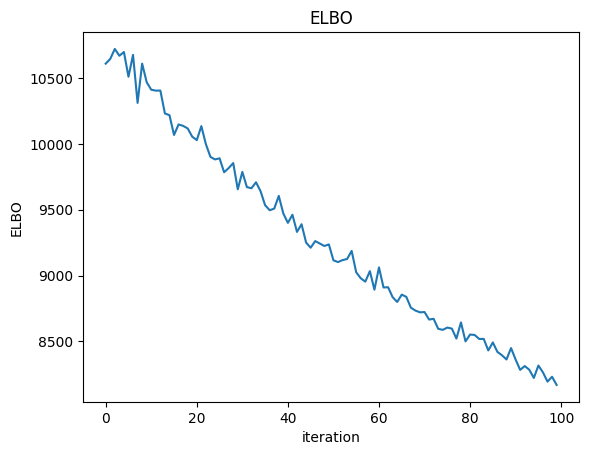

taking steps 101 to 200 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 8251.61:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 8251.61:   1%|          | 1/100 [00:06<10:11,  6.17s/it]

Mean ELBO 8224.11:   1%|          | 1/100 [00:12<10:11,  6.17s/it]

...

Mean ELBO 7341.20:  98%|█████████▊| 98/100 [10:33<00:12,  6.46s/it]

Mean ELBO 7341.20:  99%|█████████▉| 99/100 [10:33<00:06,  6.42s/it]

Mean ELBO 7335.33:  99%|█████████▉| 99/100 [10:39<00:06,  6.42s/it]

Mean ELBO 7335.33: 100%|██████████| 100/100 [10:39<00:00,  6.41s/it]

Mean ELBO 7335.33: 100%|██████████| 100/100 [10:39<00:00,  6.40s/it]

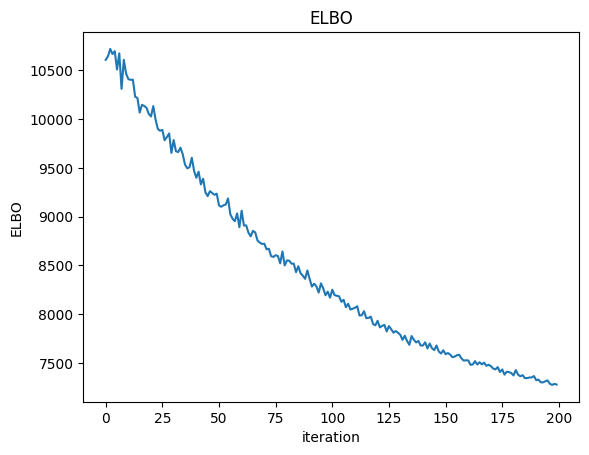

taking steps 201 to 300 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 7287.09:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 7287.09:   1%|          | 1/100 [00:06<11:24,  6.91s/it]

Mean ELBO 7284.06:   1%|          | 1/100 [00:13<11:24,  6.91s/it]

...

Mean ELBO 6986.88:  98%|█████████▊| 98/100 [10:33<00:12,  6.29s/it]

Mean ELBO 6986.88:  99%|█████████▉| 99/100 [10:33<00:06,  6.37s/it]

Mean ELBO 6984.30:  99%|█████████▉| 99/100 [10:40<00:06,  6.37s/it]

Mean ELBO 6984.30: 100%|██████████| 100/100 [10:40<00:00,  6.46s/it]

Mean ELBO 6984.30: 100%|██████████| 100/100 [10:40<00:00,  6.40s/it]

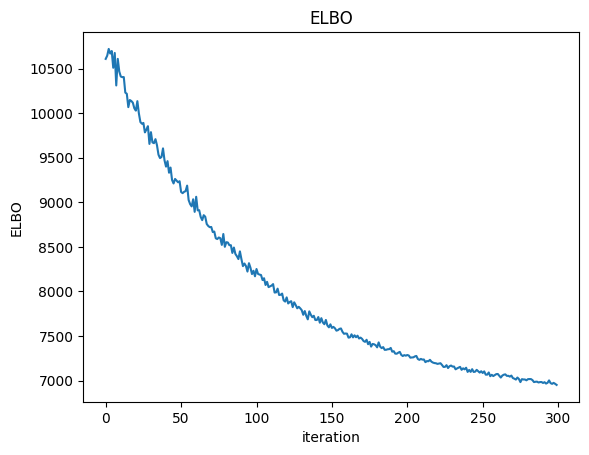

taking steps 301 to 400 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 6976.92:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 6976.92:   1%|          | 1/100 [00:06<10:29,  6.36s/it]

Mean ELBO 6968.23:   1%|          | 1/100 [00:12<10:29,  6.36s/it]

...

Mean ELBO 6828.21:  98%|█████████▊| 98/100 [10:34<00:13,  6.51s/it]

Mean ELBO 6828.21:  99%|█████████▉| 99/100 [10:34<00:06,  6.48s/it]

Mean ELBO 6827.45:  99%|█████████▉| 99/100 [10:41<00:06,  6.48s/it]

Mean ELBO 6827.45: 100%|██████████| 100/100 [10:41<00:00,  6.48s/it]

Mean ELBO 6827.45: 100%|██████████| 100/100 [10:41<00:00,  6.41s/it]

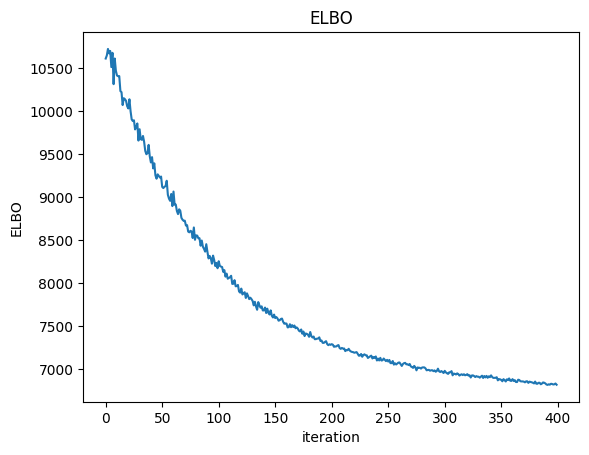

taking steps 401 to 500 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 6809.84:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 6809.84:   1%|          | 1/100 [00:06<11:30,  6.97s/it]

Mean ELBO 6806.40:   1%|          | 1/100 [00:13<11:30,  6.97s/it]

...

Mean ELBO 6733.41:  98%|█████████▊| 98/100 [10:38<00:12,  6.29s/it]

Mean ELBO 6733.41:  99%|█████████▉| 99/100 [10:38<00:06,  6.22s/it]

Mean ELBO 6734.43:  99%|█████████▉| 99/100 [10:45<00:06,  6.22s/it]

Mean ELBO 6734.43: 100%|██████████| 100/100 [10:45<00:00,  6.48s/it]

Mean ELBO 6734.43: 100%|██████████| 100/100 [10:45<00:00,  6.45s/it]

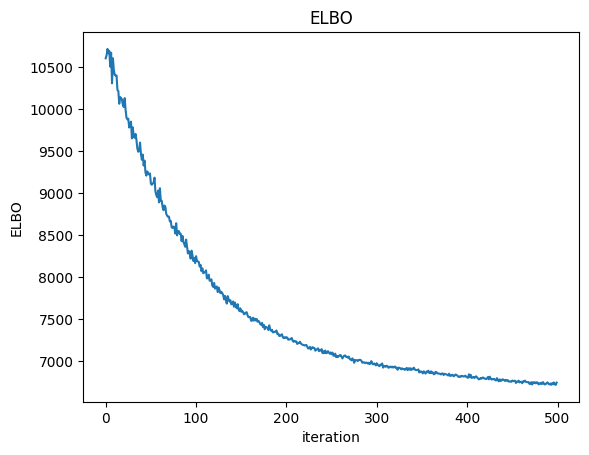

taking steps 501 to 600 out of total 600


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 6722.45:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 6722.45:   1%|          | 1/100 [00:06<10:25,  6.32s/it]

Mean ELBO 6720.69:   1%|          | 1/100 [00:12<10:25,  6.32s/it]

...

Mean ELBO 6658.07:  98%|█████████▊| 98/100 [11:04<00:13,  6.73s/it]

Mean ELBO 6658.07:  99%|█████████▉| 99/100 [11:04<00:06,  6.81s/it]

Mean ELBO 6657.40:  99%|█████████▉| 99/100 [11:10<00:06,  6.81s/it]

Mean ELBO 6657.40: 100%|██████████| 100/100 [11:10<00:00,  6.73s/it]

Mean ELBO 6657.40: 100%|██████████| 100/100 [11:10<00:00,  6.71s/it]

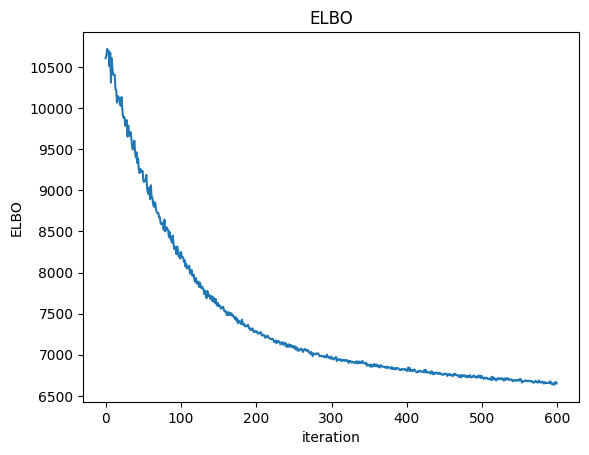

       reward rate  dec temp  cached weight  cached rate  subject
0         0.536491  0.214402       0.662405     0.889710        0
1         0.002004  4.130778       0.679360     0.718919        1
2         0.126573  1.506282       0.728630     0.030480        2
3         0.961309  1.616302       1.048405     0.999946        3
4         0.000496  1.898197       0.582248     0.985810        4
...            ...       ...            ...          ...      ...
11995     0.354322  1.004516       0.521209     0.190300       19
11996     0.958781  1.132772       1.165405     0.000097       20
11997     0.932076  0.600696       0.491657     0.805732       21
11998     0.853499  0.454908       0.715012     0.915459       22
11999     0.964187  0.682914       0.768951     0.917894       23

[12000 rows x 5 columns]


<Figure size 640x480 with 0 Axes>

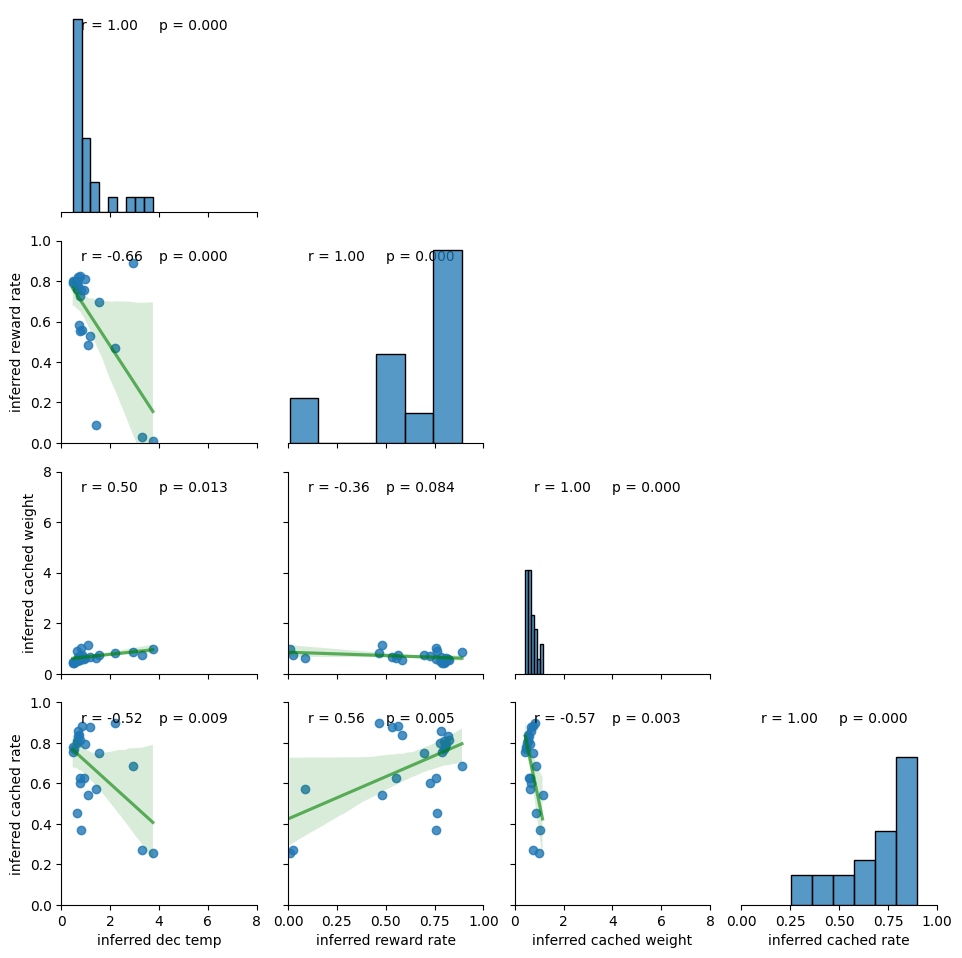

In [15]:
if run_inference:

    # remove old inference?
    remove_old = True

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=remove_old, 
                                                    use_h=use_h)
                                                    
    print('analyzing '+str(n_agents)+' data sets')

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    num_particles = 15


    print("this is inference using", type(inferrer))
    
    size_chunk = 100
    total_num_iter_so_far = 0

    for i in range(total_num_iter_so_far, num_steps, size_chunk):
        print('taking steps '+str(i+1)+' to '+str(i+size_chunk)+' out of total '+str(num_steps))

        fname_str = fname_base + str(total_num_iter_so_far+size_chunk)+'_'+str(n_agents)+'agents'

        iu.infer(inferrer, size_chunk, fname_str, num_particles, base_dir)
        total_num_iter_so_far += size_chunk

    inferrer.save_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.save_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    # sample from posterior only at last time step and save results. Could be done at every step, if earlier posteriors are of interest, one can load the inferrer save and sample from that.
    mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir, true_vals=true_vals) 
    
    plt.figure()
    vars_of_interest = ["inferred "+name for name in param_names]
    f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                        plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                        grid_kws={"layout_pad": 1.5},
                        x_vars=vars_of_interest, y_vars=vars_of_interest)
    f.map(tu.annot_corrfunc)
    for p, p_range in enumerate(param_ranges):
        f.axes[n_pars-1,p].set_xlim(p_range)
        f.axes[p,0].set_ylim(p_range)
    plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
    plt.show()

taking steps 601 to 700 out of total 1000


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 6637.70:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 6637.70:   1%|          | 1/100 [00:06<11:27,  6.94s/it]

Mean ELBO 6649.67:   1%|          | 1/100 [00:14<11:27,  6.94s/it]

...

Mean ELBO 6620.26:  98%|█████████▊| 98/100 [11:32<00:13,  6.83s/it]

Mean ELBO 6620.26:  99%|█████████▉| 99/100 [11:32<00:07,  7.03s/it]

Mean ELBO 6620.45:  99%|█████████▉| 99/100 [11:39<00:07,  7.03s/it]

Mean ELBO 6620.45: 100%|██████████| 100/100 [11:39<00:00,  6.94s/it]

Mean ELBO 6620.45: 100%|██████████| 100/100 [11:39<00:00,  7.00s/it]

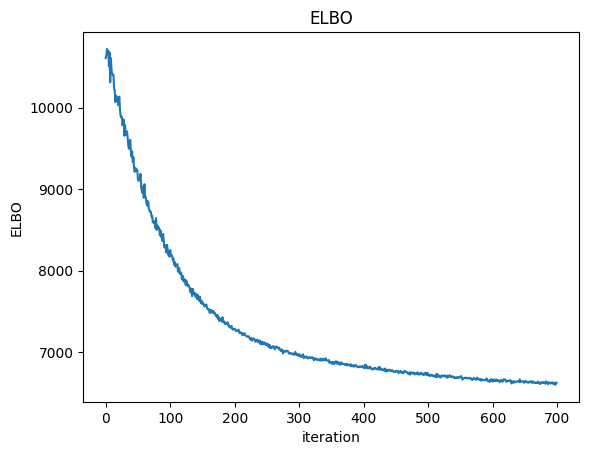

taking steps 701 to 800 out of total 1000


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 6614.77:   0%|          | 0/100 [00:07<?, ?it/s]

Mean ELBO 6614.77:   1%|          | 1/100 [00:07<12:48,  7.76s/it]

Mean ELBO 6611.01:   1%|          | 1/100 [00:14<12:48,  7.76s/it]

...

Mean ELBO 6589.89:  98%|█████████▊| 98/100 [11:35<00:14,  7.09s/it]

Mean ELBO 6589.89:  99%|█████████▉| 99/100 [11:35<00:06,  6.96s/it]

Mean ELBO 6589.21:  99%|█████████▉| 99/100 [11:43<00:06,  6.96s/it]

Mean ELBO 6589.21: 100%|██████████| 100/100 [11:43<00:00,  7.04s/it]

Mean ELBO 6589.21: 100%|██████████| 100/100 [11:43<00:00,  7.03s/it]

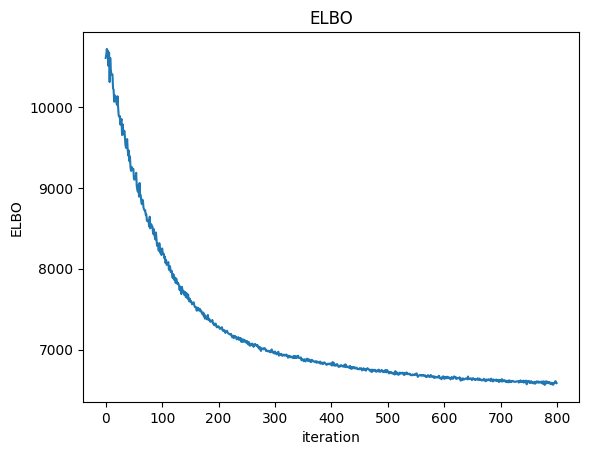

taking steps 801 to 900 out of total 1000


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 6582.12:   0%|          | 0/100 [00:06<?, ?it/s]

Mean ELBO 6582.12:   1%|          | 1/100 [00:06<11:24,  6.92s/it]

Mean ELBO 6584.71:   1%|          | 1/100 [00:13<11:24,  6.92s/it]

...

Mean ELBO 6565.27:  98%|█████████▊| 98/100 [11:25<00:14,  7.01s/it]

Mean ELBO 6565.27:  99%|█████████▉| 99/100 [11:25<00:07,  7.05s/it]

Mean ELBO 6565.34:  99%|█████████▉| 99/100 [11:32<00:07,  7.05s/it]

Mean ELBO 6565.34: 100%|██████████| 100/100 [11:32<00:00,  6.96s/it]

Mean ELBO 6565.34: 100%|██████████| 100/100 [11:33<00:00,  6.94s/it]

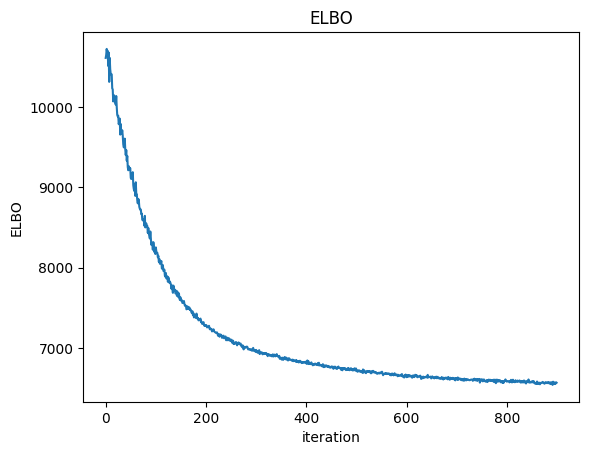

taking steps 901 to 1000 out of total 1000


  0%|          | 0/100 [00:00<?, ?it/s]

Mean ELBO 6557.27:   0%|          | 0/100 [00:07<?, ?it/s]

Mean ELBO 6557.27:   1%|          | 1/100 [00:07<12:12,  7.39s/it]

Mean ELBO 6555.26:   1%|          | 1/100 [00:14<12:12,  7.39s/it]

...

Mean ELBO 6542.47:  98%|█████████▊| 98/100 [11:36<00:14,  7.20s/it]

Mean ELBO 6542.47:  99%|█████████▉| 99/100 [11:36<00:07,  7.06s/it]

Mean ELBO 6540.61:  99%|█████████▉| 99/100 [11:43<00:07,  7.06s/it]

Mean ELBO 6540.61: 100%|██████████| 100/100 [11:43<00:00,  7.05s/it]

Mean ELBO 6540.61: 100%|██████████| 100/100 [11:43<00:00,  7.04s/it]

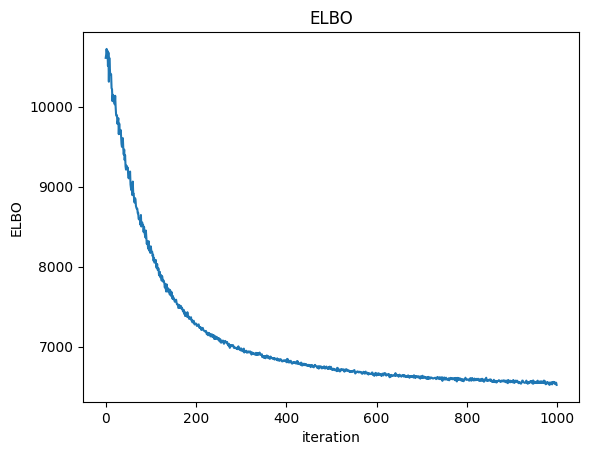

       reward rate  dec temp  cached weight  cached rate  subject
0         0.995292  0.532721       0.184560     0.562116        0
1         0.001898  3.166527       0.435846     0.005743        1
2         0.102686  1.721160       0.579233     0.999980        2
3         0.000005  0.281932       0.546267     0.000002        3
4         1.000000  0.196843       0.482002     0.992424        4
...            ...       ...            ...          ...      ...
11995     0.394317  0.794163       0.407175     0.086153       19
11996     0.945682  0.497837       1.554778     0.000004       20
11997     0.492083  0.217037       0.135147     0.015771       21
11998     0.998448  1.037112       0.377373     0.999919       22
11999     0.999781  0.648946       0.402131     0.991562       23

[12000 rows x 5 columns]


<Figure size 640x480 with 0 Axes>

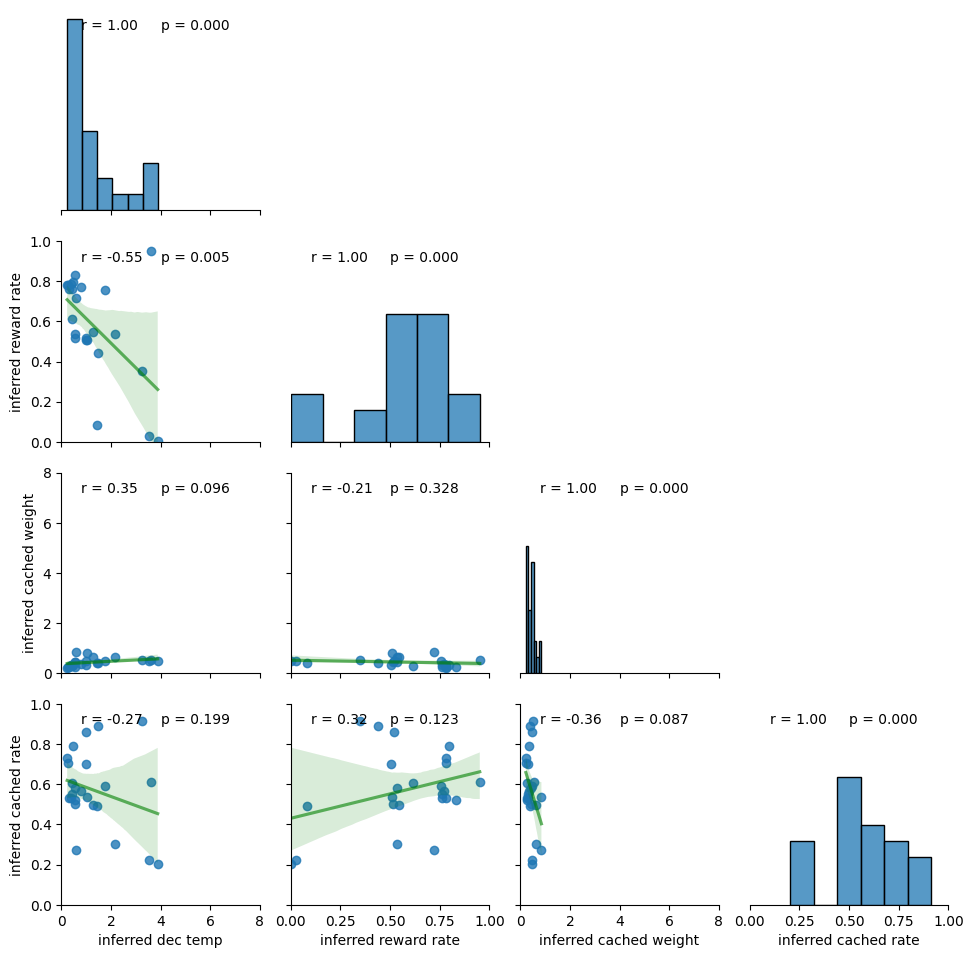

In [16]:
num_steps = 1000

for i in range(total_num_iter_so_far, num_steps, size_chunk):
    print('taking steps '+str(i+1)+' to '+str(i+size_chunk)+' out of total '+str(num_steps))

    fname_str = fname_base + str(total_num_iter_so_far+size_chunk)+'_'+str(n_agents)+'agents'

    iu.infer(inferrer, size_chunk, fname_str, num_particles, base_dir)
    total_num_iter_so_far += size_chunk

    inferrer.save_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.save_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

# sample from posterior only at last time step and save results. Could be done at every step, if earlier posteriors are of interest, one can load the inferrer save and sample from that.
mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir, true_vals=true_vals) 

plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    grid_kws={"layout_pad": 1.5},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()

<b>Or:</b> Set up agent and inference. Load past inference, decide whether to resample posterior or used stored samples

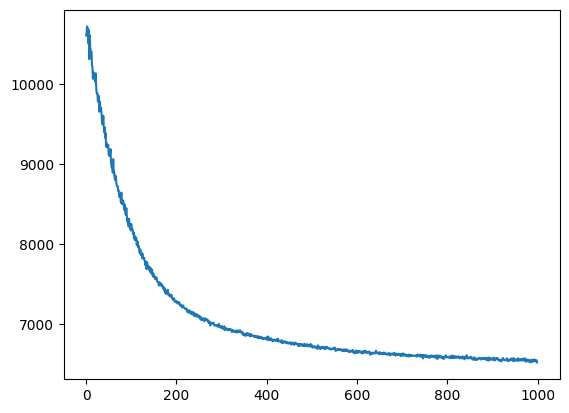

last ELBO: tensor(6519.7705)


In [17]:
if not run_inference:

    # set up agent
    bayes_agent = tu.set_up_Bayesian_inference_agent(n_agents, learn_rewards, learn_habit, learn_cached, base_dir, 
                                                    global_experiment_parameters, data["valid"], remove_old=False, 
                                                    use_h=use_h)
                                                    
    print('analyzing '+str(n_agents)+' data sets')

    resample = True

    # set up inference
    inferrer = inf.GeneralGroupInference(bayes_agent, data)

    fname_str = fname_base + str(num_steps)+'_'+str(n_agents)+'agents'

    inferrer.load_parameters(os.path.join(base_dir, fname_str+"_parameter.save"))

    inferrer.load_elbo(os.path.join(base_dir, fname_str+"_elbo.save"))

    if resample:
        mean_df, sample_df, locs_df = iu.sample_posterior(inferrer, param_names, fname_str, base_dir, true_vals=true_vals) 
    else:
        mean_df, sample_df, locs_df = iu.load_samples(base_dir, fname_str) 

plt.figure()
plt.plot(inferrer.loss)
plt.show()
print("last ELBO:", inferrer.loss[-1])

<Figure size 640x480 with 0 Axes>

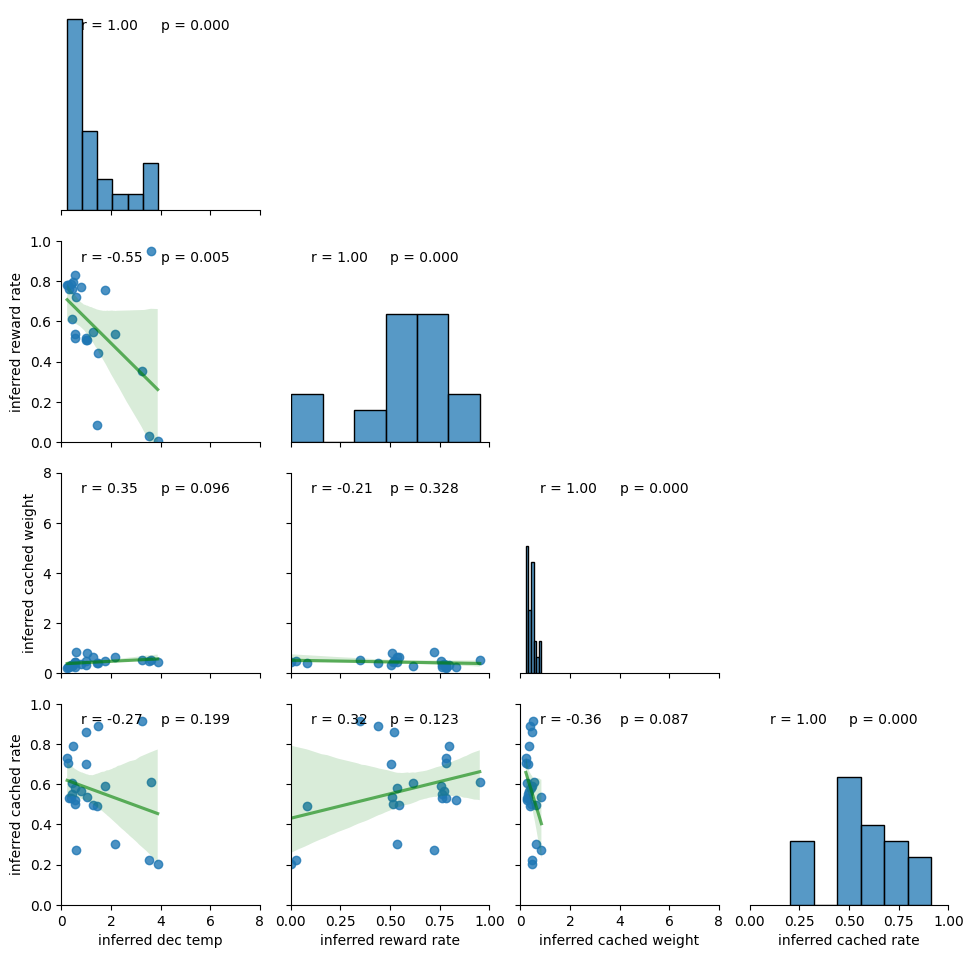

This is recovery for the twostage task using the Bayesian prior-based contextual control model(BCC_4pars_planning_cached) with 24 agents.
The settings are: learn habit - False


In [18]:
plt.figure()
vars_of_interest = ["inferred "+name for name in param_names]
f = sns.pairplot(data=mean_df, kind='reg', diag_kind="hist", corner=True,
                    plot_kws={'line_kws': {'color': 'green', 'alpha': 0.6}},
                    grid_kws={"layout_pad": 1.5},
                    x_vars=vars_of_interest, y_vars=vars_of_interest)
f.map(tu.annot_corrfunc)
for p, p_range in enumerate(param_ranges):
    f.axes[n_pars-1,p].set_xlim(p_range)
    f.axes[p,0].set_ylim(p_range)
plt.savefig(os.path.join(base_dir, fname_str+"_pairplot_means_inferred_corr.svg"))
plt.show()
        
print("This is recovery for the twostage task using the "+model_name+"("+agent_type+")"+" with "+str(n_agents)+" agents.")
print("The settings are: learn habit - "+str(learn_habit))

/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/inference_utils.py:137: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  (r, p) = pearsonr(plot_df["true "+name], plot_df["inferred "+name])
/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/inference_utils.py:150: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pval = plot_df.corr(method=lambda x, y: pearsonr(x, y)[1]) - eye(*rho.shape)


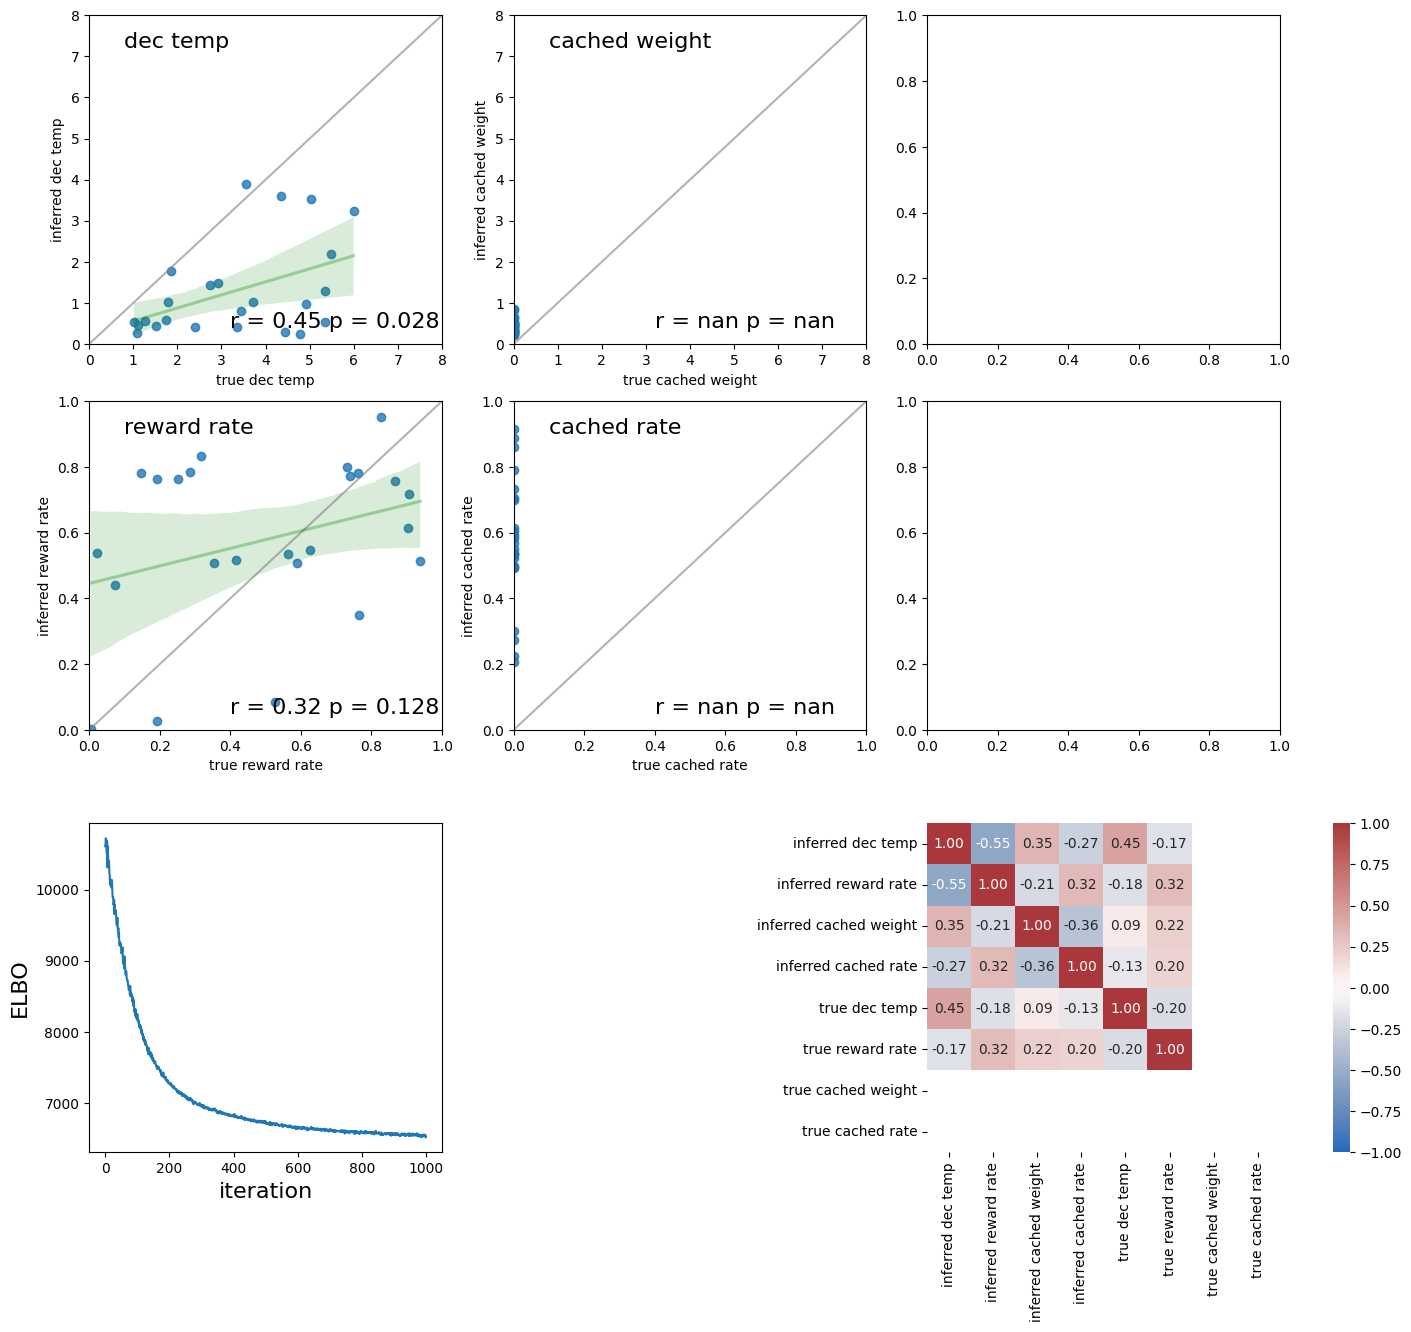

/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/misc.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  (r, p) = pearsonr(x, y)
/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/misc.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  (r, p) = pearsonr(x, y)
/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/misc.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  (r, p) = pearsonr(x, y)
/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/misc.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  (r, p) = pearsonr(x, y)
/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/mi

<Figure size 640x480 with 0 Axes>

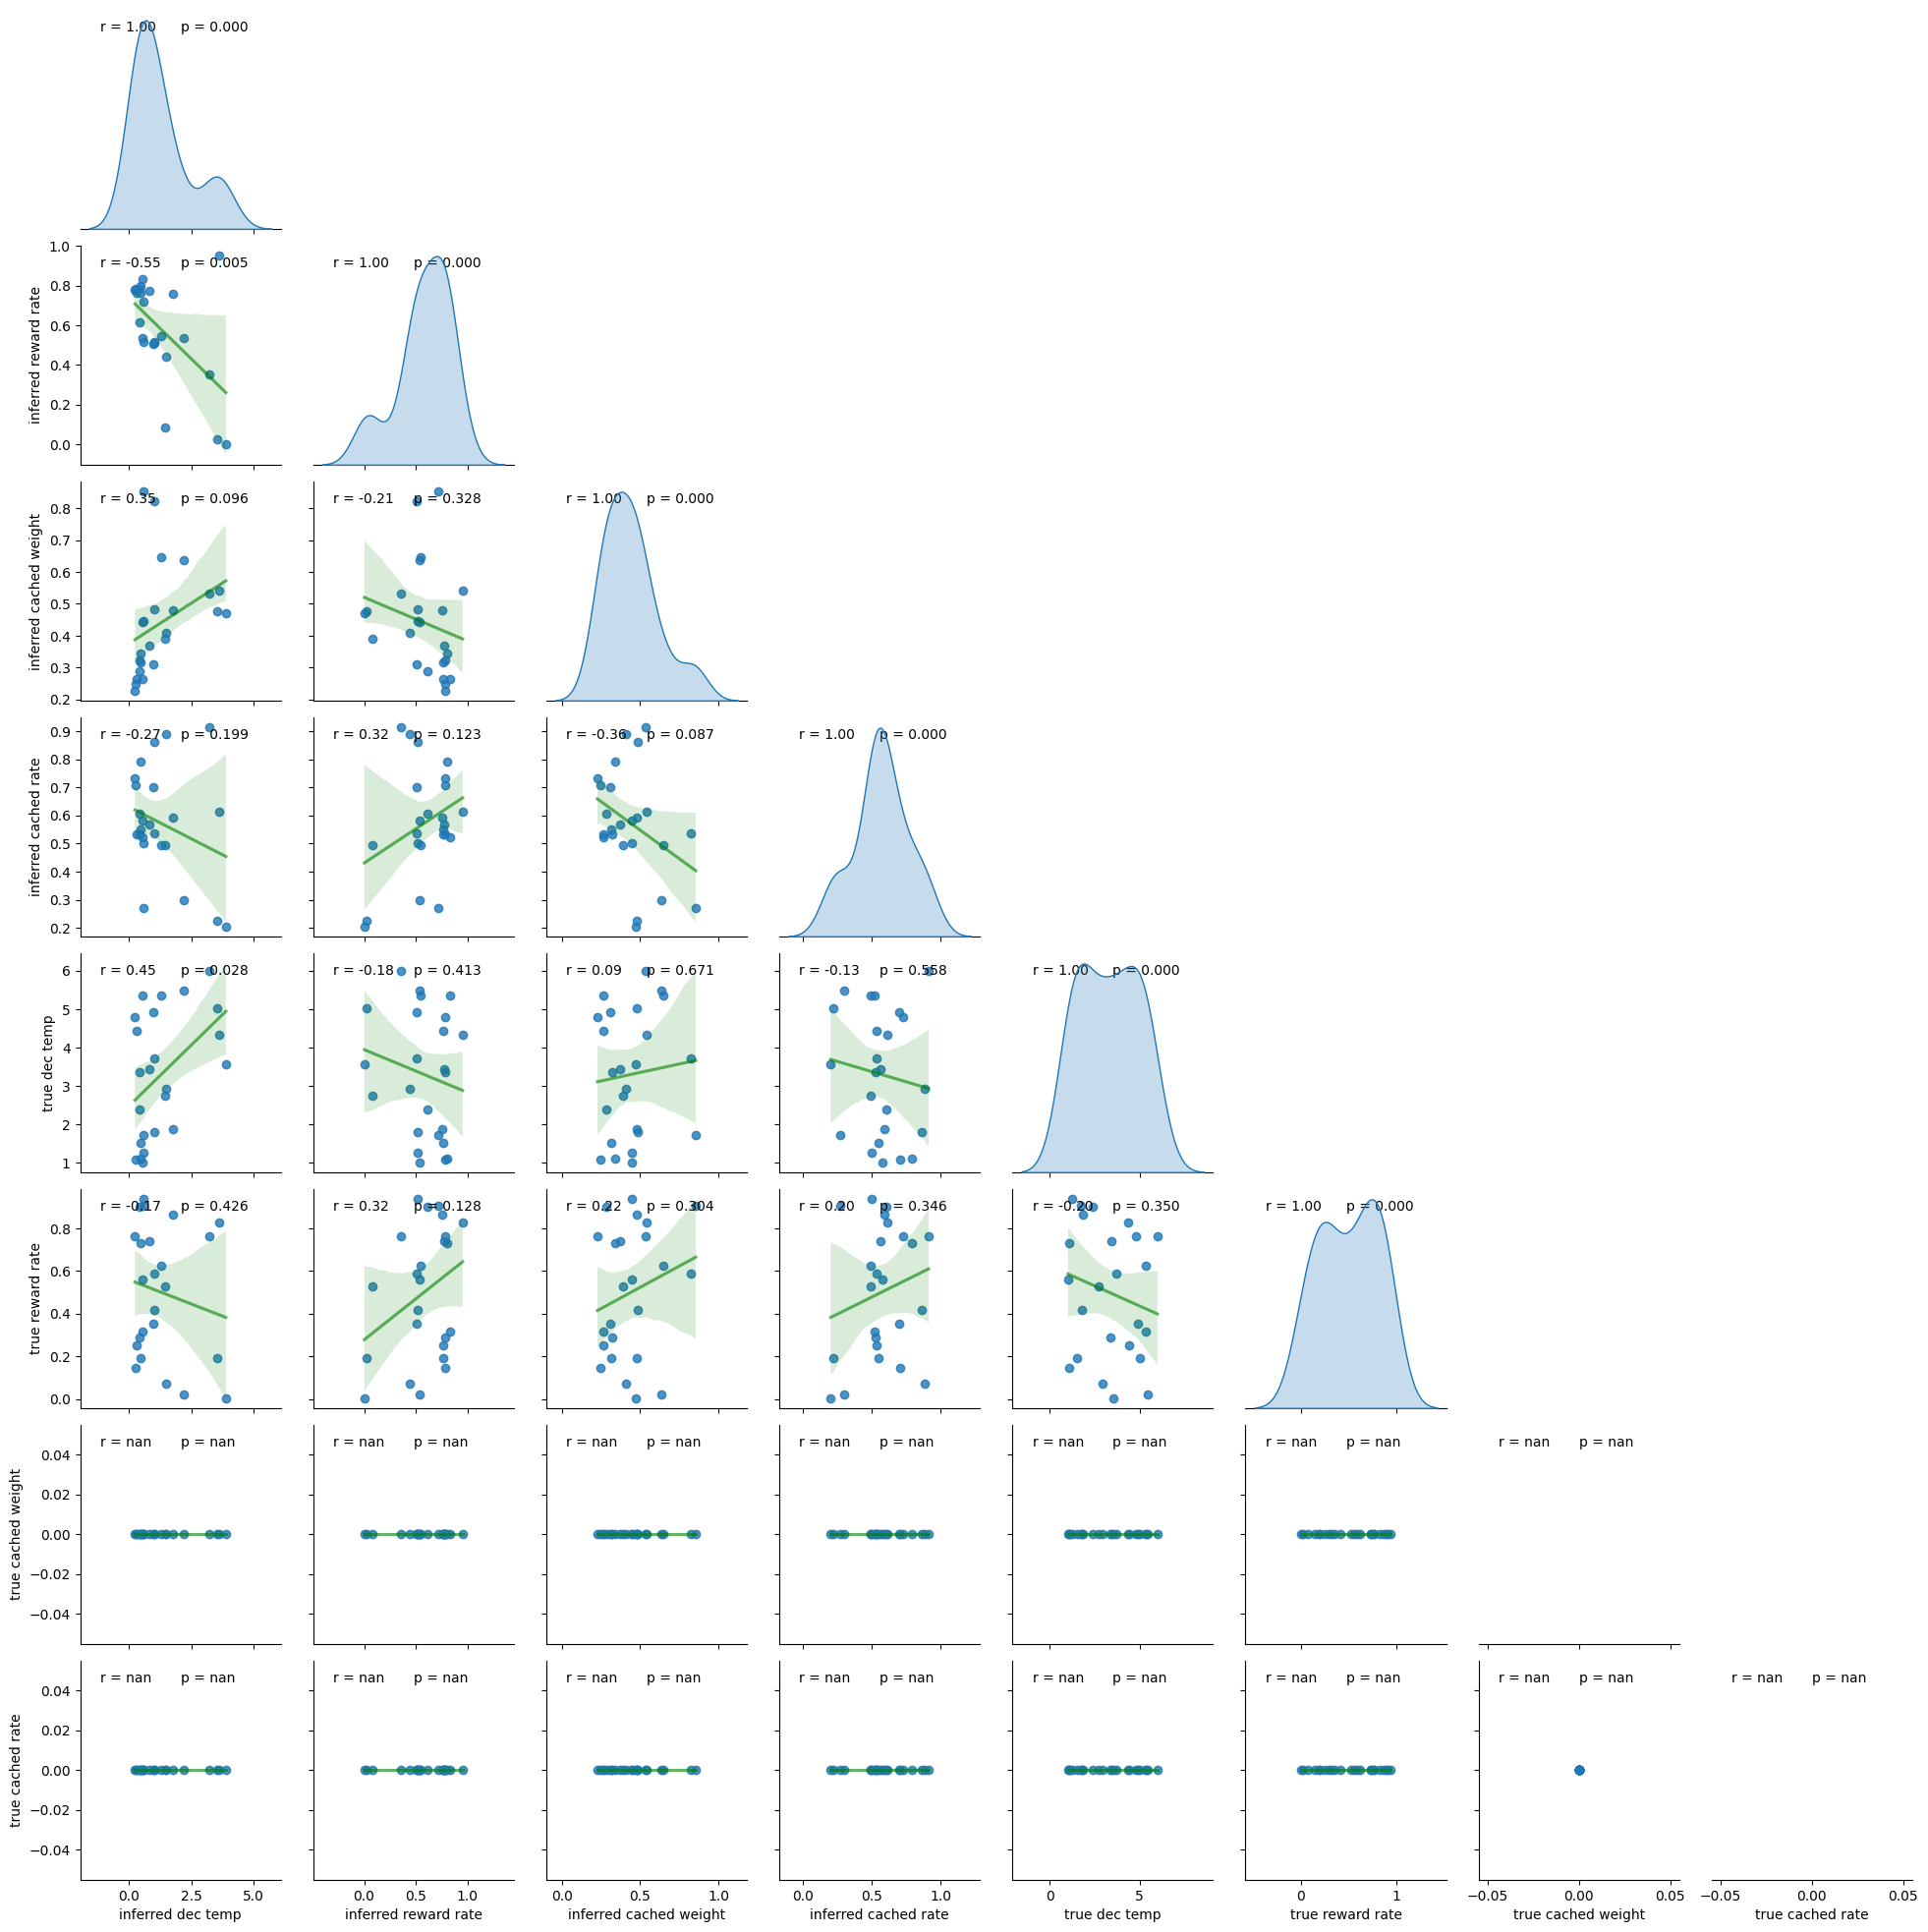

/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/misc.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  (r, p) = pearsonr(x, y)
/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/misc.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  (r, p) = pearsonr(x, y)
/home/sarah/src/TwoStageStrategies/FeherDaSilva_data/magic_carpet/../../code/BalancingControl/misc.py:27: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  (r, p) = pearsonr(x, y)


<Figure size 640x480 with 0 Axes>

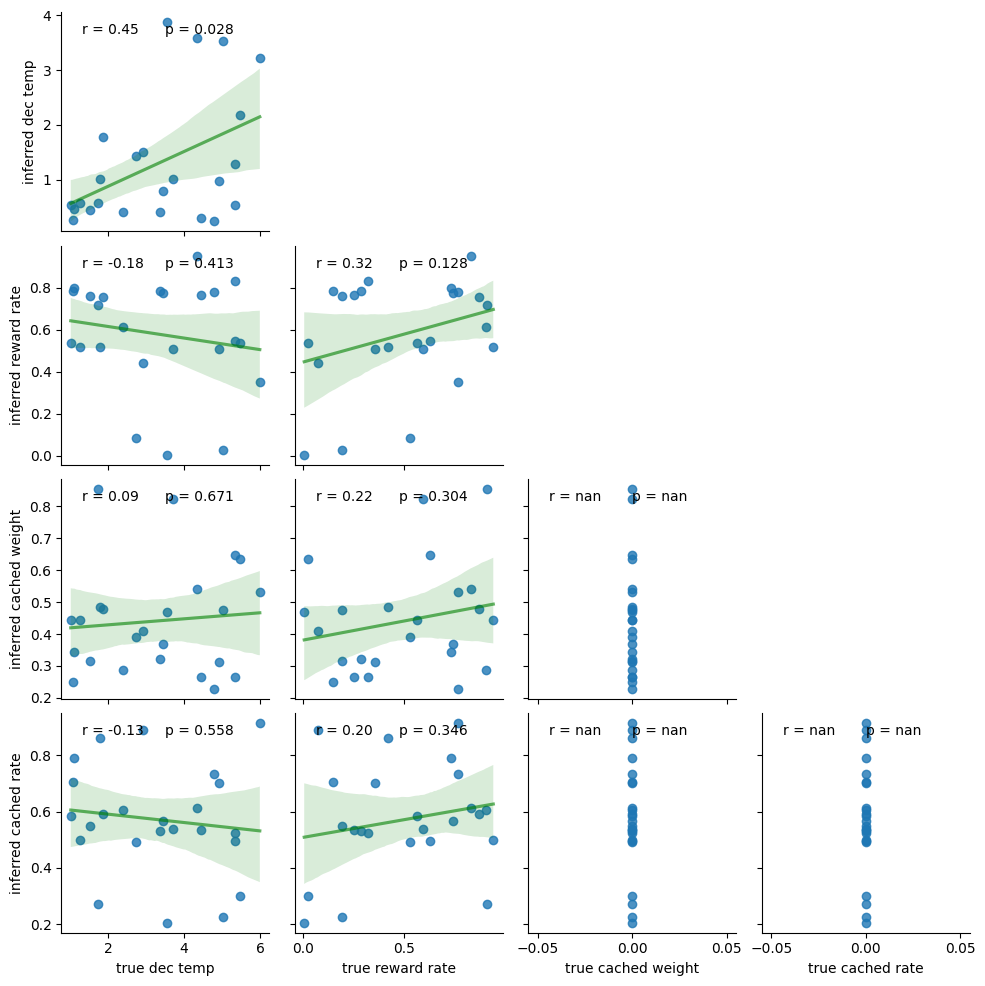

<Figure size 640x480 with 0 Axes>

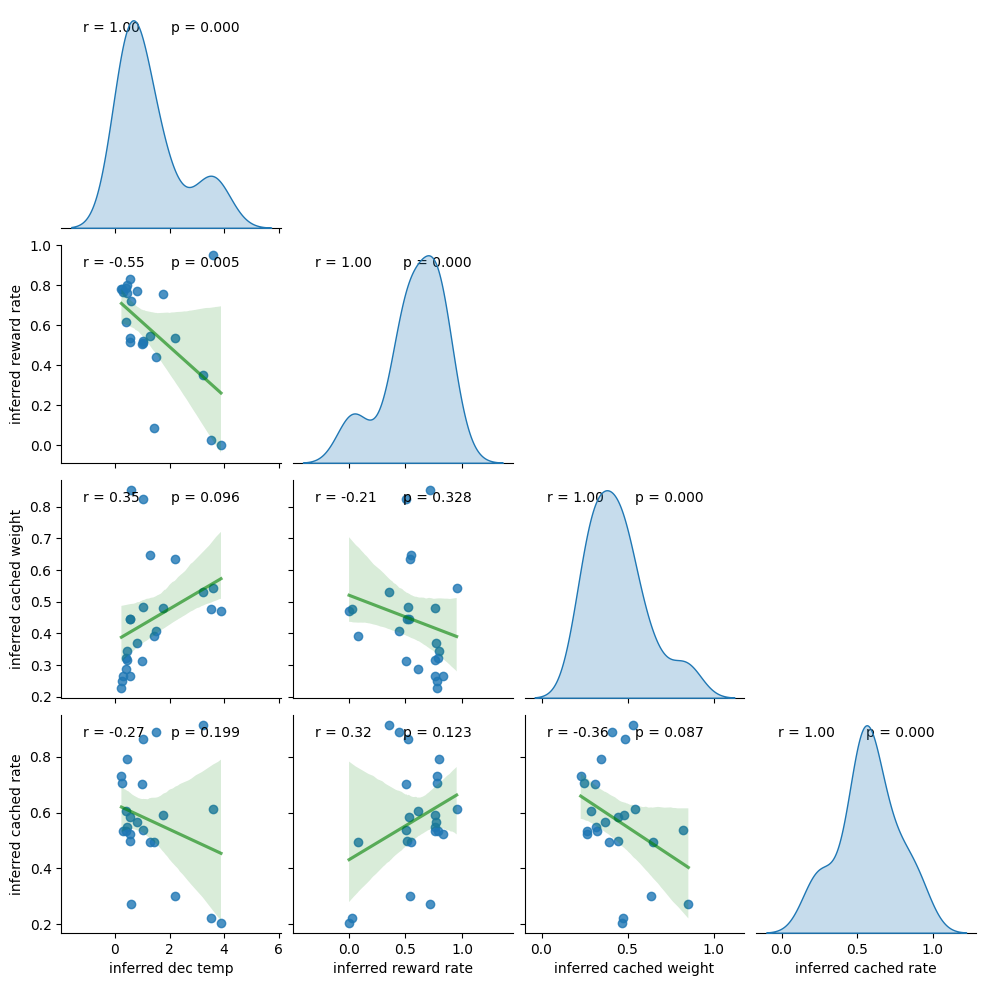

In [19]:
iu.plot_results(sample_df, param_names, fname_str, inferrer.loss, mean_df, base_dir, param_ranges)